# Analysis of ScopeM data

In [133]:
# Imports
import re
from pathlib import Path
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from tifffile import imread
from cellpose.metrics import aggregated_jaccard_index, average_precision

plt.rcParams["font.family"] = "Arial"

In [148]:
# Data and save paths
root_path = Path("../data/processed/segmented/Au_01-vol_01.zarr")
gt_root = Path("../data/processed/labeled/Au_01-vol_01/labeled-03/labels")

save_root = Path("../data/figures/paper/amira")
save_root.mkdir(exist_ok=True, parents=True)

In [46]:
# Load data
root = zarr.open_group(root_path)

cells_amira = root.get("amira/cells/filtered/50-50-50")
nuclei_amira = root.get("amira/nuclei/filtered/50-50-50")

cells = root.get("labels/cells/masks/50-50-50")
nuclei = root.get("labels/nuclei/masks/50-50-50")

In [48]:
gt_cells_paths = list(gt_root.glob("*virt*cells*"))
gt_nuclei_paths = list(gt_root.glob("*virt*nuclei*"))

In [52]:
y_start, y_stop, x_start, x_stop = cells_amira.attrs["processing"][0]["crop"]

In [69]:
def process_gt(path: Path) -> dict:
    match = re.search(r"([x|y])_(\d+)-", path.name)
    axis = match.group(1)
    idx = int(match.group(2))
    gt = imread(path)

    if axis == "x":
        gt = gt[:, y_start:y_stop]
        idx -= x_start
        indexer = np.s_[:, :, idx]
    elif axis == "y":
        gt = gt[:, x_start:x_stop]
        idx -= y_start
        indexer = np.s_[:, idx, :]

    return {"gt": gt, "indexer": indexer, "path": path}

In [71]:
gt_cells = [process_gt(i) for i in gt_cells_paths]
gt_nuclei = [process_gt(i) for i in gt_nuclei_paths]

In [138]:
iou_th = 0.75

results = []
results.extend(
    [
        {
            "name": i["path"].name,
            "agg_jaccard": aggregated_jaccard_index(
                [i["gt"]], [cells_amira[i["indexer"]]]
            )[0],
            "avg_precision": average_precision(
                [i["gt"]], [cells_amira[i["indexer"]]], threshold=[iou_th]
            )[0][0][0],
            "seg_target": "cells",
            "model": "Amira",
        }
        for i in gt_cells
    ]
)
results.extend(
    [
        {
            "name": i["path"].name,
            "agg_jaccard": aggregated_jaccard_index([i["gt"]], [cells[i["indexer"]]])[
                0
            ],
            "avg_precision": average_precision(
                [i["gt"]], [cells[i["indexer"]]], threshold=[iou_th]
            )[0][0][0],
            "seg_target": "cells",
            "model": "Finetuned",
        }
        for i in gt_cells
    ]
)
results.extend(
    [
        {
            "name": i["path"].name,
            "agg_jaccard": aggregated_jaccard_index(
                [i["gt"]], [nuclei_amira[i["indexer"]]]
            )[0],
            "avg_precision": average_precision(
                [i["gt"]], [nuclei_amira[i["indexer"]]], threshold=[iou_th]
            )[0][0][0],
            "seg_target": "nuclei",
            "model": "Amira",
        }
        for i in gt_nuclei
    ]
)
results.extend(
    [
        {
            "name": i["path"].name,
            "agg_jaccard": aggregated_jaccard_index([i["gt"]], [nuclei[i["indexer"]]])[
                0
            ],
            "avg_precision": average_precision(
                [i["gt"]], [nuclei[i["indexer"]]], threshold=[iou_th]
            )[0][0][0],
            "seg_target": "nuclei",
            "model": "Finetuned",
        }
        for i in gt_nuclei
    ]
)

/Users/boda/Library/Caches/pypoetry/virtualenvs/sphero-vem-S4wgO9hY-py3.12/lib/python3.12/site-packages/cellpose/metrics.py:176: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)


In [139]:
data = pd.DataFrame(results)

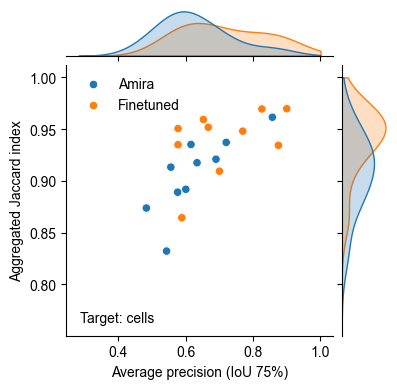

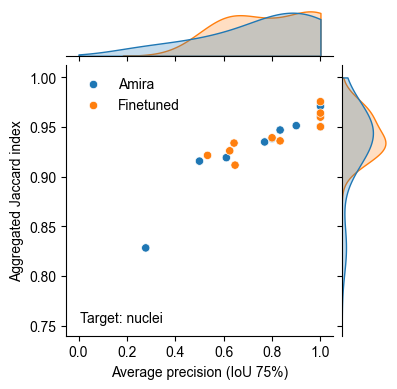

In [149]:
# Cells
# fig, ax = plt.subplots()
clip_boundaries = [0, 1]
for seg_target in ["cells", "nuclei"]:
    g = sns.jointplot(
        data.query(f"seg_target=='{seg_target}'"),
        x="avg_precision",
        y="agg_jaccard",
        hue="model",
        marginal_kws={
            "clip": clip_boundaries,  # Truncate the density curve at 0 and 1
            "linewidth": 1,
            # 'alpha': 0.,
        },
        height=4,
    )

    leg = g.ax_joint.get_legend()
    leg.set_title("")
    leg.set_frame_on(False)

    g.ax_joint.set(
        xlabel="Average precision (IoU 75%)", ylabel="Aggregated Jaccard index"
    )
    g.ax_joint.text(
        x=0.05,
        y=0.05,
        s=f"Target: {seg_target}",
        transform=g.ax_joint.transAxes,
    )
    g.savefig(
        save_root / f"amira-metrics-comparison-{seg_target}.pdf",
        bbox_inches="tight",
        pad_inches=0.01,
    )